In [2]:
import sys
import os 
import pandas as pd
import numpy as np
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.analysis.sensitivity import SensitivityAnalyzer
from omegaconf import OmegaConf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
import random
import itertools

In [3]:
parameter_ranges = OmegaConf.load('../param_config.yaml')

In [ ]:
alphapem_path = r"D:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\external\AlphaPEM"
sys.path.append(alphapem_path)
final_df = pd.read_pickle("../sampling_test/validated_final_df.pkl"0)

In [4]:
final_df.classification.value_counts()

classification
valid                27708
invalid                942
invalid_no_output       22
Name: count, dtype: int64

## Calculate distances to generate the proxy "predictions"

We just calculated those for the instances that we didn't have an output due to computational constrains

In [46]:
final_df_valid_cmpl = final_df.loc[final_df.classification=="valid"]
final_df_valid = final_df_valid_cmpl[parameter_ranges.keys()]
final_df_no_output_cmpl = final_df.loc[final_df.classification=="invalid_no_output"]
final_df_no_output = final_df_no_output_cmpl[parameter_ranges.keys()]
print(f' shape valid {final_df_valid.shape} & shape no output {final_df_no_output.shape}')

 shape valid (27708, 13) & shape no output (22, 13)


In [ ]:
final_df_no_output.to_csv('../data/raw/configurations_wo_output.csv')

In [16]:
combined_df = pd.concat([final_df_valid, final_df_no_output], ignore_index=True)

# Apply StandardScaler
scaler = StandardScaler()
combined_scaled = scaler.fit_transform(combined_df)

# Split back into query and database sets
query_scaled = combined_scaled[:len(final_df_valid)]
database_scaled = combined_scaled[len(final_df_valid):]

# Compute distance matrix (Euclidean)
distance_matrix = pairwise_distances(database_scaled,query_scaled, metric='euclidean')
print(f'shape distances {distance_matrix.shape}')


shape distances (22, 27708)


In [36]:
k = 10  # or whatever number of neighbors you want
nearest_indices = np.argsort(distance_matrix, axis=1)[:, :k]
# If you want the distances too
nearest_distances = np.sort(distance_matrix, axis=1)[:, :k]


In [24]:
np.max(distance_matrix)

np.float64(8.776555261584619)

In [30]:
# Calculate statistics for the distance_matrix
min_dist = np.min(distance_matrix)
mean_dist = np.mean(distance_matrix)
max_dist = np.max(distance_matrix)
percentiles = np.percentile(distance_matrix, [5, 10, 25, 75, 90])

print(f"Min: {min_dist}")
print(f"Mean: {mean_dist}")
print(f"Max: {max_dist}")
print(f"5th percentile: {percentiles[0]}")
print(f"10th percentile: {percentiles[1]}")
print(f"25th percentile: {percentiles[2]}")
print(f"75th percentile: {percentiles[3]}")
print(f"90th percentile: {percentiles[4]}")

Min: 0.5435690625380997
Mean: 5.44116907383502
Max: 8.776555261584619
5th percentile: 3.997441239657334
10th percentile: 4.335637826186038
25th percentile: 4.885050550308105
75th percentile: 6.027192432600576
90th percentile: 6.50777110798781


In [37]:
nearest_indices

array([[18878, 14021, 14020, 14013, 14022, 14019, 14010, 14014, 14011,
        14700],
       [ 1172,  1165,  1164,  1162,  1171,  1170,  1166,  1161, 25539,
         1163],
       [ 1172,  1165,  1164,  1162,  1171,  1170,  1166,  1161,  1163,
         1169],
       [ 7582,  7572,  7580,  7571,  7581,  7578,  7575,  7574,  7579,
         7573],
       [ 7582,  7572,  7580,  7571,  7581,  7578,  7575,  7574,  7579,
        16482],
       [ 8477,  8472,  8471,  8466,  8473,  8474,  8468,  8469,  5235,
         5241],
       [12008, 12006, 12007, 14016,  8476, 12009, 14013, 12018, 14021,
        27235],
       [12008, 12006, 12007,  8476,  6805, 14016, 12018,  2446, 27235,
        12009],
       [12008, 12006, 12007, 14016,  8476, 12009, 14013, 27235, 14021,
        12018],
       [12008, 12006, 12007, 14016,  8476, 12009, 12018, 27235, 14013,
         5703],
       [12008, 12006, 12007, 14013, 14021, 24678, 14014, 14010, 14019,
        14011],
       [12008, 12006, 12007, 14016,  8476, 

In [38]:
[max(dis) for dis in nearest_distances]

[np.float64(2.2819796452791934),
 np.float64(1.889735070708354),
 np.float64(2.1564057118326443),
 np.float64(2.184253410440449),
 np.float64(2.0116887112658666),
 np.float64(2.2377622118797373),
 np.float64(2.5444710675794284),
 np.float64(2.537376484305163),
 np.float64(2.526201464164384),
 np.float64(2.594552081184402),
 np.float64(2.2518261100710317),
 np.float64(2.5437805568286276),
 np.float64(2.580606246153335),
 np.float64(2.539498144968458),
 np.float64(2.4061306062773817),
 np.float64(2.5642953842027),
 np.float64(1.7171244204449443),
 np.float64(1.951915750390025),
 np.float64(1.5488103379809033),
 np.float64(2.490333386325005),
 np.float64(2.1143901554059203),
 np.float64(2.034468241540771)]

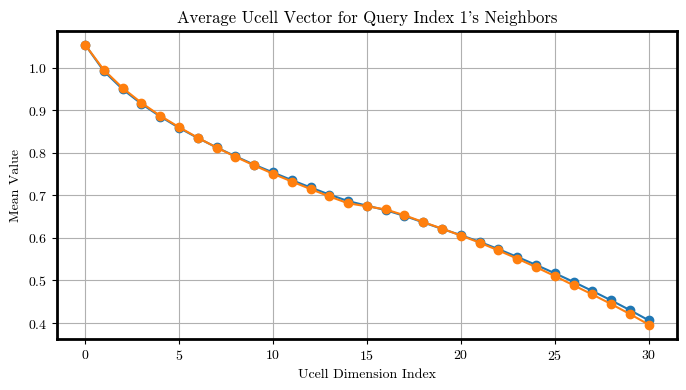

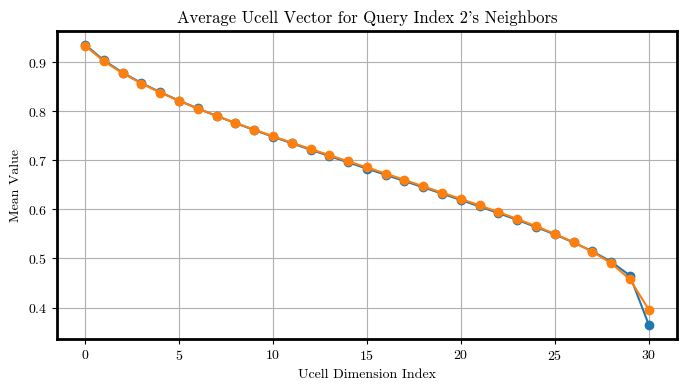

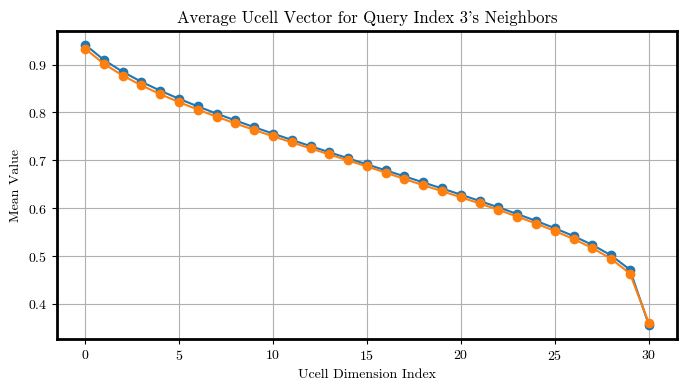

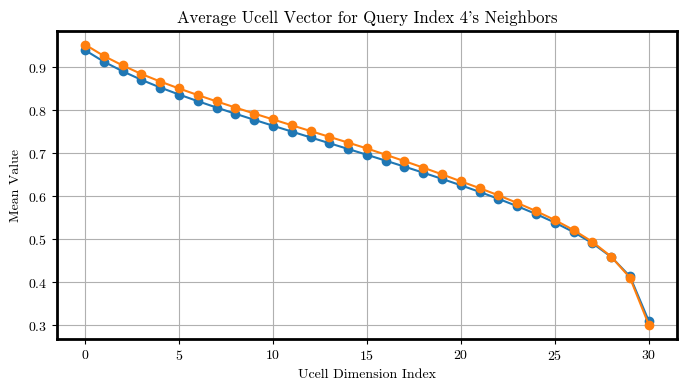

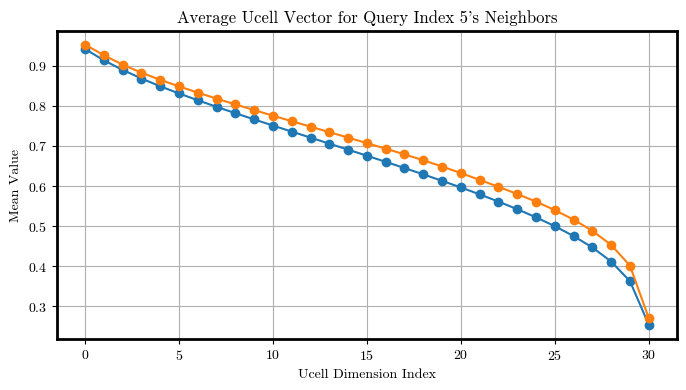

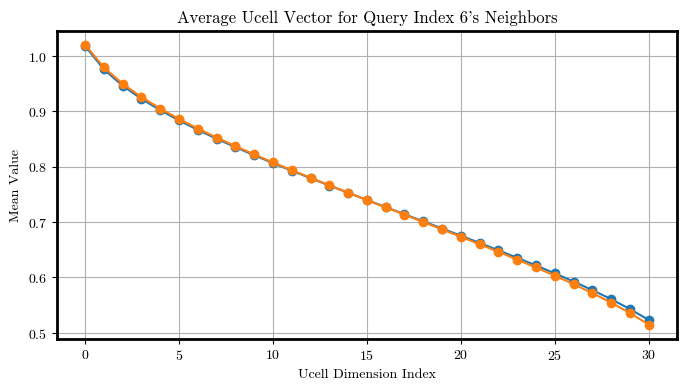

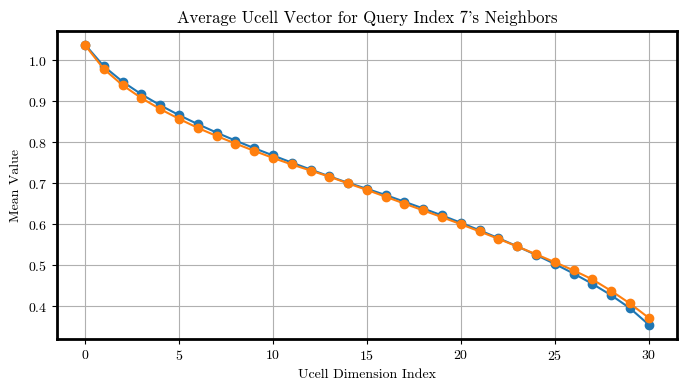

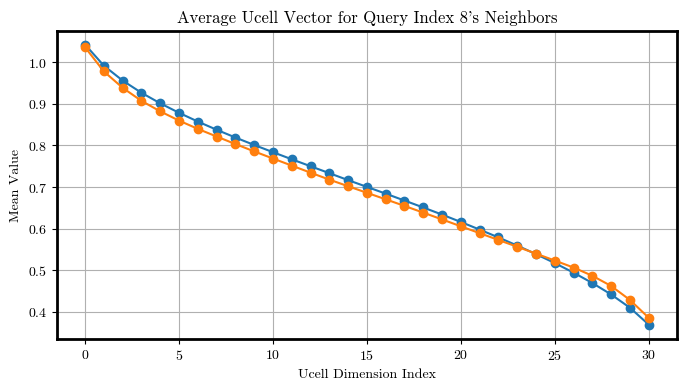

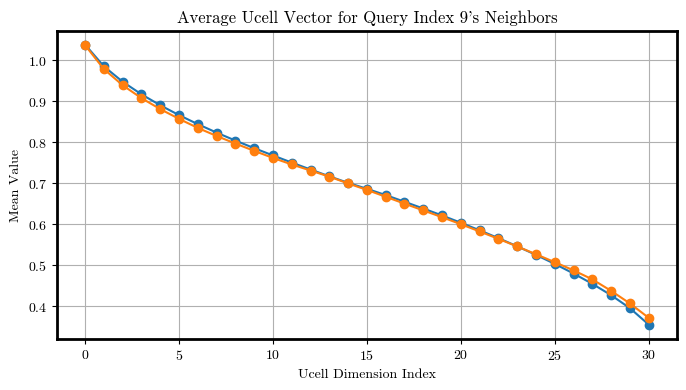

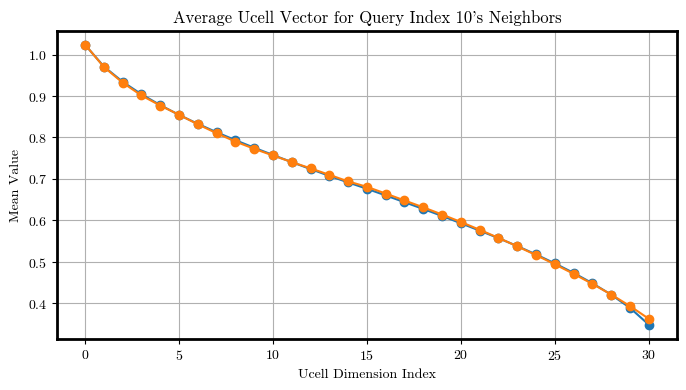

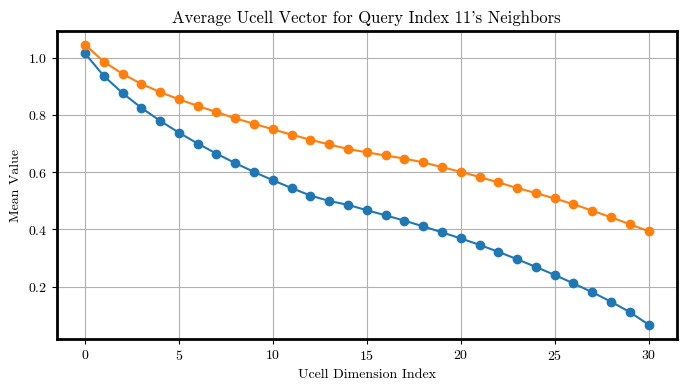

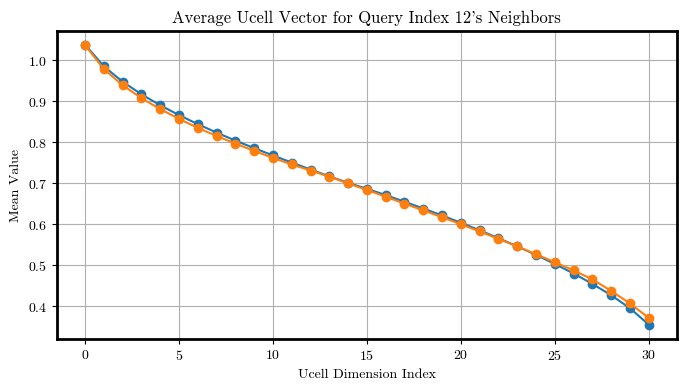

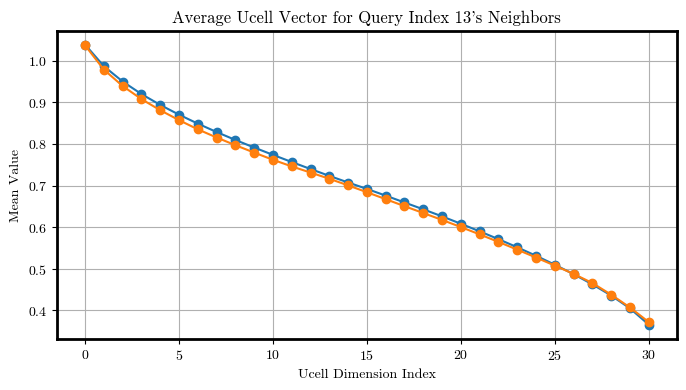

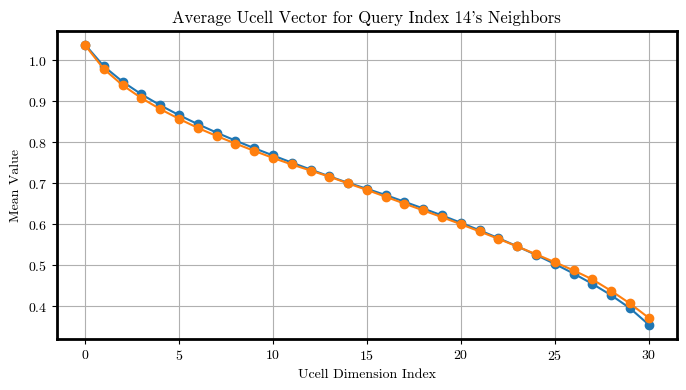

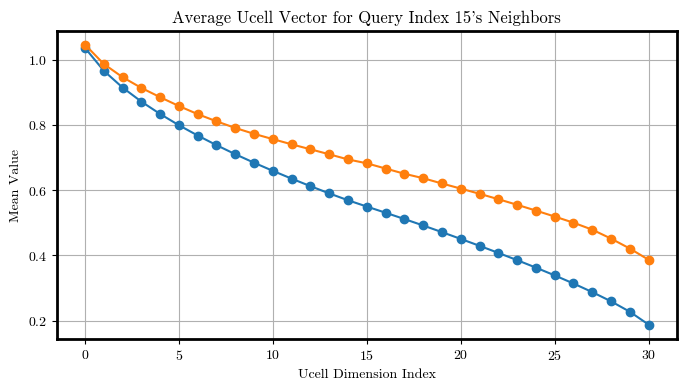

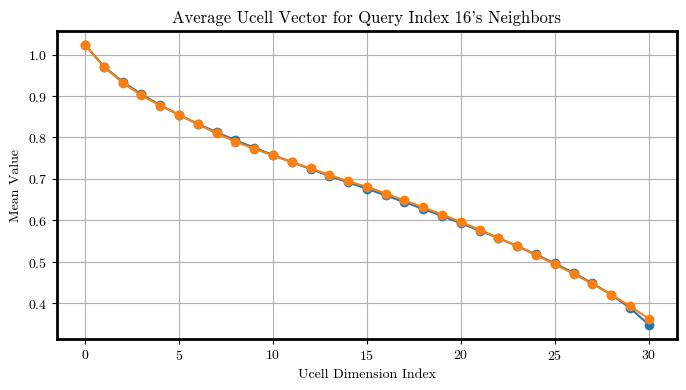

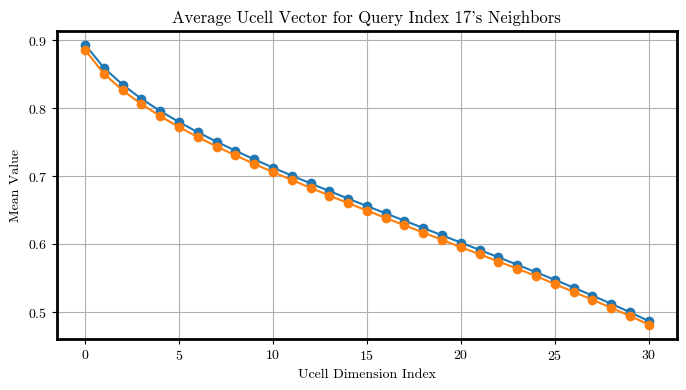

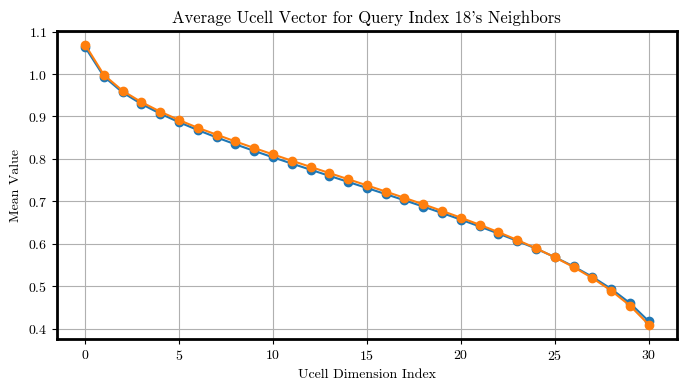

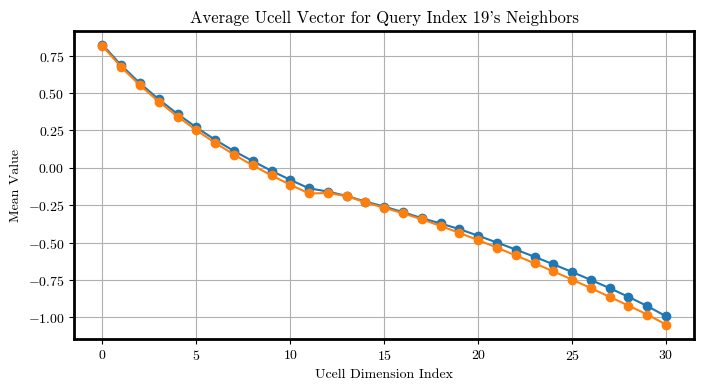

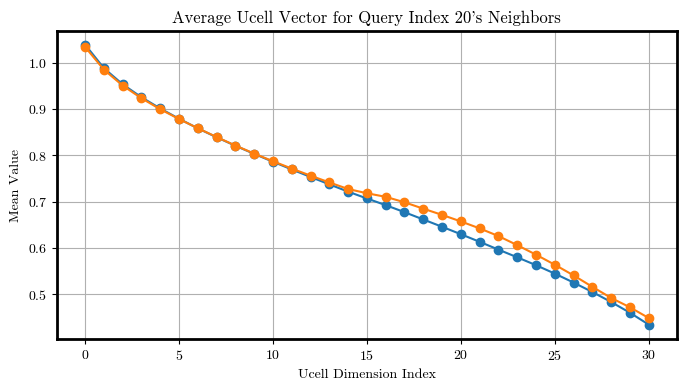

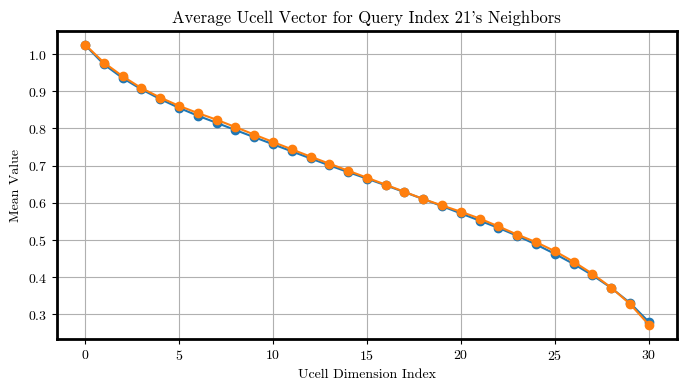

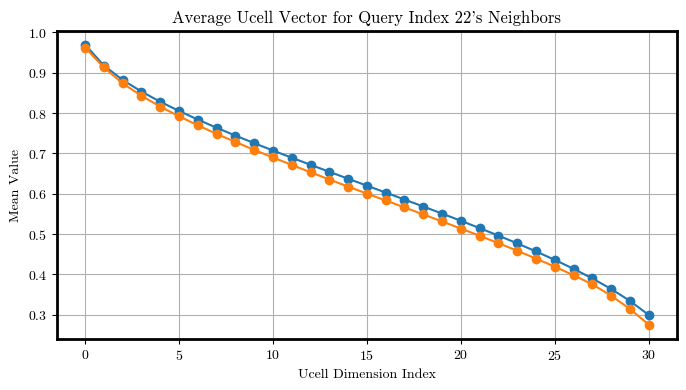

In [77]:
import matplotlib.pyplot as plt
outputs_knn_mean=[]
outputs_knn_median=[]

ifc_outputs_knn_mean=[]
for i, neighbors in enumerate(nearest_indices):
    ifc_mean = np.stack(final_df_valid_cmpl.iloc[neighbors]['ifc']).mean(axis=0)
    ifc_outputs_knn_mean.append(ifc_mean)
    ucell_mean = np.stack(final_df_valid_cmpl.iloc[neighbors]['Ucell']).mean(axis=0)
    ucell_median = np.median(np.stack(final_df_valid_cmpl.iloc[neighbors]['Ucell']), axis=0)
    outputs_knn_mean.append(ucell_mean)
    outputs_knn_median.append(ucell_median)

    # plot 
    plt.figure(figsize=(8, 4))
    plt.plot(ucell_mean, marker='o', linestyle='-')
    plt.plot(ucell_median, marker='o', linestyle='-')
    plt.title(f"Average Ucell Vector for Query Index {i+1}'s Neighbors")
    plt.xlabel("Ucell Dimension Index")
    plt.ylabel("Mean Value")
    plt.grid(True)
    plt.show()

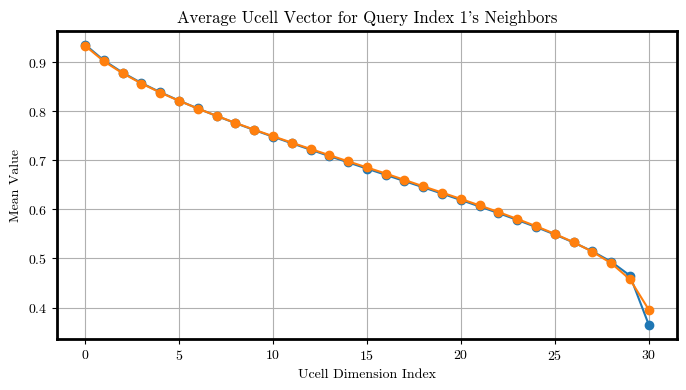

In [ ]:

import numpy as np


In [68]:
df_mean_missing = pd.DataFrame(np.stack(outputs_knn_mean),columns=[f'Ucell_{i}' for i in range(len(outputs_knn_mean[0]))])
df_median_missing = pd.DataFrame(np.stack(outputs_knn_median),columns=[f'Ucell_{i}' for i in range(len(outputs_knn_median[0]))])

We validate the synthetic curves

In [69]:
from src.validity.validity_criteria import validate_polarization_curves
criteria = {
         "start_in_range": True,
         "early_values_in_range": True,
         "monotonic": False,
         "approx_monotonic":True
     }
validated_df_mean_missing = validate_polarization_curves(
    df_mean_missing,
    apply_criteria=criteria,
    filter_invalid=False,
    keep_temp_cols = False,
    approx_monotonic_threshold=0.05
)

validated_df_median_missing = validate_polarization_curves(
    df_median_missing,
    apply_criteria=criteria,
    filter_invalid=False,
    keep_temp_cols = False,
    approx_monotonic_threshold=0.05
)

print(f'Mean:{validated_df_mean_missing.classification.value_counts()},{validated_df_mean_missing.classification.value_counts(normalize=True)}')
print(f'Median:{validated_df_median_missing.classification.value_counts()},{validated_df_median_missing.classification.value_counts(normalize=True)}')

Mean:classification
valid    22
Name: count, dtype: int64,classification
valid    1.0
Name: proportion, dtype: float64
Median:classification
valid    22
Name: count, dtype: int64,classification
valid    1.0
Name: proportion, dtype: float64


As both cases all curves were valid, we're going to impute the mean

In [80]:
final_df_no_output_cmpl['Ucell'] = outputs_knn_mean
final_df_no_output_cmpl['ifc'] = ifc_outputs_knn_mean

C:\Users\Camila Bermudez\AppData\Local\Temp\ipykernel_16076\3828107004.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df_no_output_cmpl['Ucell'] = outputs_knn_mean
C:\Users\Camila Bermudez\AppData\Local\Temp\ipykernel_16076\3828107004.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df_no_output_cmpl['ifc'] = ifc_outputs_knn_mean


In [ ]:
ifc_df_mean_missing = pd.DataFrame(np.stack(ifc_outputs_knn_mean),columns=[f'ifc_{i}' for i in range(len(outputs_knn_mean[0]))])
repeated_cols = ifc_df_mean_missing.columns.to_list()+ df_mean_missing.columns.to_list()
final_df_no_output_cmpl_T = pd.concat([final_df_no_output_cmpl.drop(columns=repeated_cols).reset_index(drop=True), ifc_df_mean_missing,df_mean_missing], axis=1)
final_df_no_output_cmpl_T.index = final_df_no_output_cmpl.index

**We unify the valid and invalid curves with the ones we imputed**

In [124]:
final_df_others_cmpl = final_df.loc[final_df.classification!="invalid_no_output"]
final_imputed = pd.concat([final_df_others_cmpl,final_df_no_output_cmpl_T],axis=0)
final_imputed = final_imputed.sort_index()

In [125]:
pd.DataFrame(final_imputed).to_pickle("../data/raw/final_imputed.pkl")

###  **Part 2. We perform the sobol analysis**

In [5]:
alphapem_path = r"D:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\external\AlphaPEM"
sys.path.append(alphapem_path)
final_imputed = pd.read_pickle("../data/raw/final_imputed.pkl")

In [14]:
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.analysis.sensitivity import SensitivityAnalyzer

In [ ]:
parameter_ranges = OmegaConf.load('../param_config.yaml')
dependent_parameter_names = ['Pc_des']
dependent_parameters = [{'parameter_name': 'Pc_des', 'function': lambda Pa_des : Pa_des - 20000, 'dependent_param': 'Pa_des'}]

SA = SensitivityAnalyzer(parameter_ranges, dependent_parameter_names=None, method='sobol', seed=42, N=128 , calculate_second_order=True)


unscaled = SA.generate_samples()
rescaled = SA.rescale_samples()
samples = SA.apply_dependent_parameters(dependent_parameters)

,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,i0_c_ref,kappa_co,kappa_c,Pc_des
0,345.931298,268431.866782,2.632068,0.132128,0.624495,3.519430,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.952710,248431.866782
1,350.820492,268431.866782,2.632068,0.132128,0.624495,3.519430,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.952710,248431.866782
2,345.931298,201919.596742,2.632068,0.132128,0.624495,3.519430,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.952710,181919.596742
3,345.931298,268431.866782,1.789658,0.132128,0.624495,3.519430,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.952710,248431.866782
4,345.931298,268431.866782,2.632068,0.145910,0.624495,3.519430,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.952710,248431.866782
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3579,357.141786,218225.752093,1.535442,0.576896,0.656774,2.228205,0.228680,0.268379,4,0.000003,3.605056,20.287596,2.398945,198225.752093
3580,357.141786,218225.752093,1.535442,0.576896,0.656774,2.228205,0.228680,0.268379,4,0.000005,33.521137,20.287596,2.398945,198225.752093
3581,357.141786,218225.752093,1.535442,0.576896,0.656774,2.228205,0.228680,0.268379,4,0.000005,3.605056,16.576962,2.398945,198225.752093
3582,357.141786,218225.752093,1.535442,0.576896,0.656774,2.228205,0.228680,0.268379,4,0.000005,3.605056,20.287596,1.557878,198225.752093


d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


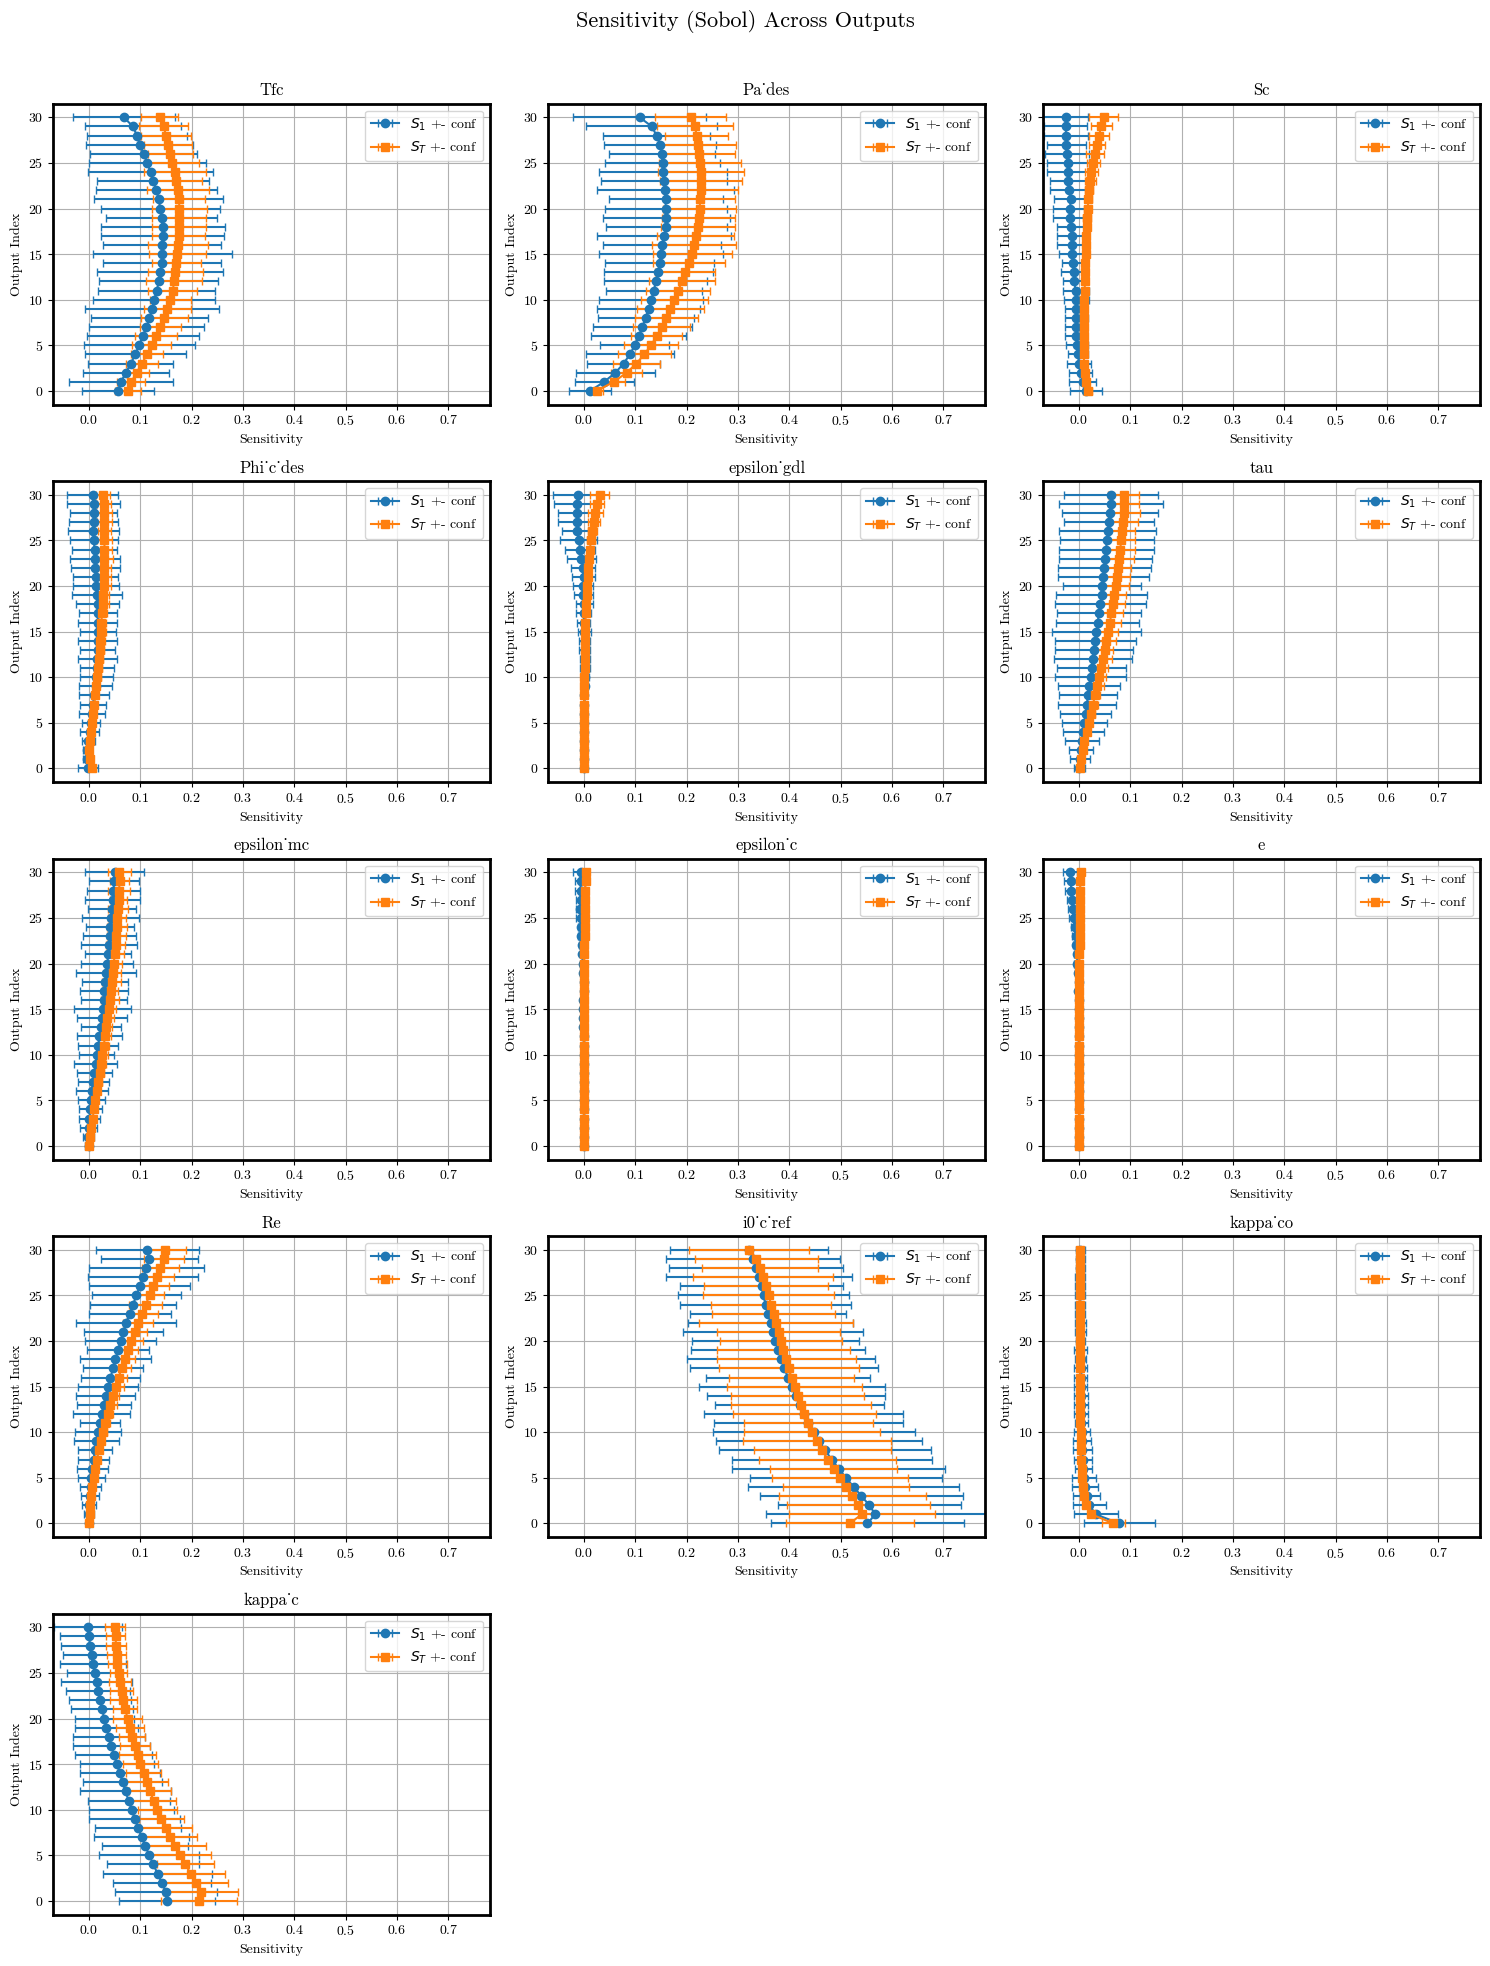

In [17]:
SA = SensitivityAnalyzer(parameter_ranges, dependent_parameter_names=None, method='sobol', seed=42, N=128 , calculate_second_order=True)
samples = SA.generate_samples()
cols = list(samples.columns)
cols.append('Ucell')
cols.append('ifc')
results = SA.run_analysis(final_imputed[cols][:len(samples)], by_regions=None, aggregation_method=None)
SA.plot_grid(results)

In [136]:
def format_output(rankings):
    rows = []
    for i, feature_dict in enumerate(rankings):
        for feature, values in feature_dict.items():
            row = {
                'id': Ns[i],  # your ID list
                'feature': feature
            }
            # Add region columns dynamically inside the loop
            for region_idx, val in enumerate(values):
                row[f'region_{region_idx}'] = val

            rows.append(row)  # Append inside the inner loop so every feature gets a row

    # Create the DataFrame
    df_rankings = pd.DataFrame(rows)
    return df_rankings


def compute_rankings_for_Ns(parameter_ranges, data, Ns, aggregation_method, by_regions,calculate_second_order=False):
    rankings = []
    indices =[]
    indicess1 =[]
    param_names = None

    for N in Ns:
        SA = SensitivityAnalyzer(
            parameter_ranges,
            dependent_parameter_names=None,
            method='sobol',
            seed=42,
            N=N,
            calculate_second_order=calculate_second_order
        )
        samples = SA.generate_samples()
        subdata = data.iloc[:len(samples)]
        results = SA.run_analysis(subdata, aggregation_method=aggregation_method, by_regions= by_regions)

        # grab ST for output_index 0
        if param_names is None:
            param_names = results[0]['param']

        rank_outputs = []
        indices_outputs =[]
        indices_s1_outputs =[]
        for i in range(len(results)):
            st = next(r['ST'] for r in results if r['output_index'] == i)
            s1 = next(r['S1'] for r in results if r['output_index'] == i)
            
            order = np.argsort(-st)     # descending
            ranks = np.empty_like(order)
            ranks[order] = np.arange(1, len(st)+1)
            rank_outputs.append(ranks)
            indices_outputs.append(st)
            indices_s1_outputs.append(st)

        rankings.append(dict(zip(param_names, np.stack(rank_outputs).T)))
        indices.append(dict(zip(param_names, np.stack(indices_outputs).T)))
        indicess1.append(dict(zip(param_names, np.stack(indices_s1_outputs).T)))
    
    df_rankings =  format_output(rankings)
    df_indices =  format_output(indices)
    df_indicess1 =  format_output(indicess1)

 
    return df_rankings,df_indices,df_indicess1


In [137]:
# 1) build the full N list
Ns = list(range(2, 513, 4))   # [2, 6, 10, …, 254]

# 2) compute rank_df however you have it
rank_df,indices_df,indices_s1 = compute_rankings_for_Ns(parameter_ranges, final_imputed, Ns, aggregation_method="sum",by_regions=True)


d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))
d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\scipy\stats\_qmc.py:993: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)
d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or

In [138]:
indices_s1

,id,feature,region_0,region_1,region_2
0,2,Tfc,0.471560,6.380313,1.630286
1,2,Pa_des,0.765588,8.655402,1.774238
2,2,Sc,0.550327,4.292354,1.123719
3,2,Phi_c_des,0.596656,4.754890,1.214663
4,2,epsilon_gdl,0.714853,6.017166,1.638703
...,...,...,...,...,...
1659,510,e,0.770147,0.777752,0.754992
1660,510,Re,0.803931,0.799370,0.769235
1661,510,i0_c_ref,0.843216,0.863311,0.854948
1662,510,kappa_co,0.883642,0.892110,0.883669


In [118]:
# Example Ns list (sample sizes)
def plot_rankings(rank_df,Ns):
    Ns = sorted(rank_df['id'].unique())

    regions = [col for col in rank_df.columns if col.startswith('region_')]

    for region in regions:
        plt.figure(figsize=(10, 6))
        cmap = plt.get_cmap('tab20', len(rank_df['feature'].unique()))

        for idx, feature in enumerate(rank_df['feature'].unique()):
            # Filter rows for the current feature
            feature_data = rank_df[rank_df['feature'] == feature]
            # Sort by sample size id to get consistent order
            feature_data = feature_data.set_index('id').loc[Ns]

            # Get ranking values for current region
            y = feature_data[region]

            plt.plot(Ns, y, color=cmap(idx), label=feature)

        plt.gca().invert_yaxis()
        plt.xticks([2, 32, 64, 96, 128, 256, 512])
        plt.xlabel("Sample size N")
        plt.ylabel("Rank (1 = most important)")
        plt.title(f"Sobol Total-Order Ranking vs. N for {region} (Distinct Colors)")
        plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize="small", ncol=1)
        plt.tight_layout()
        plt.show()


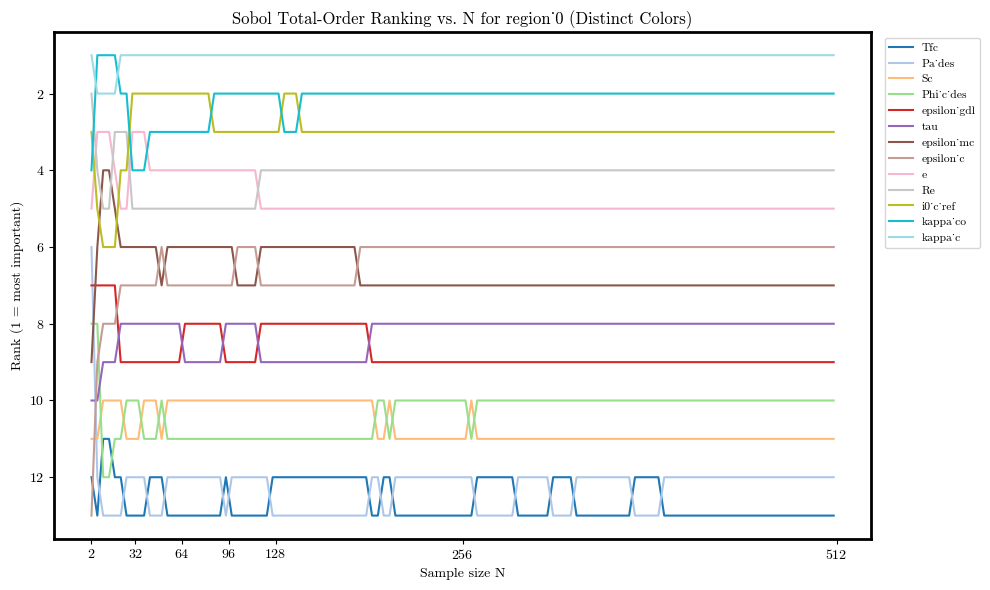

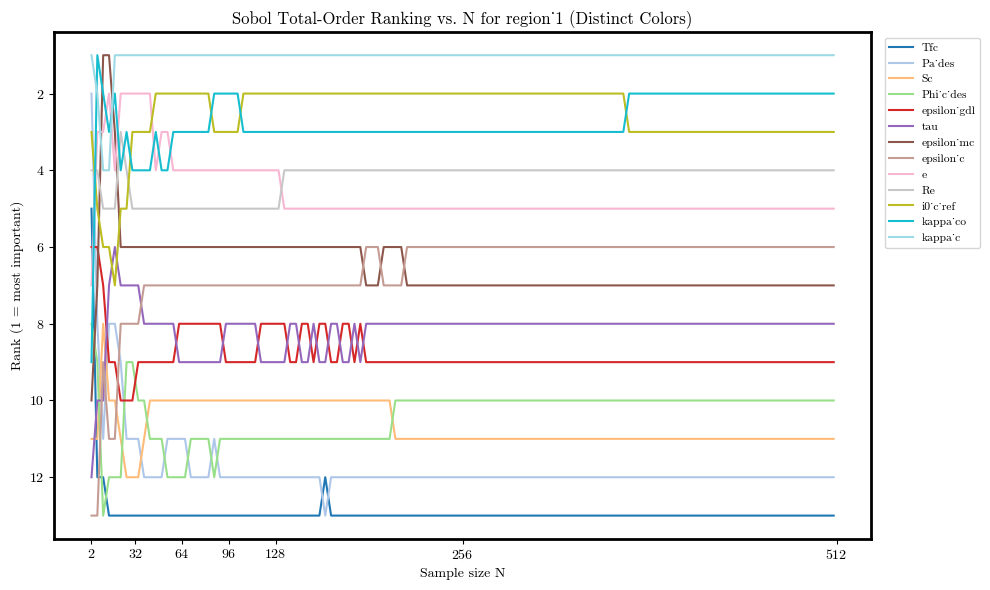

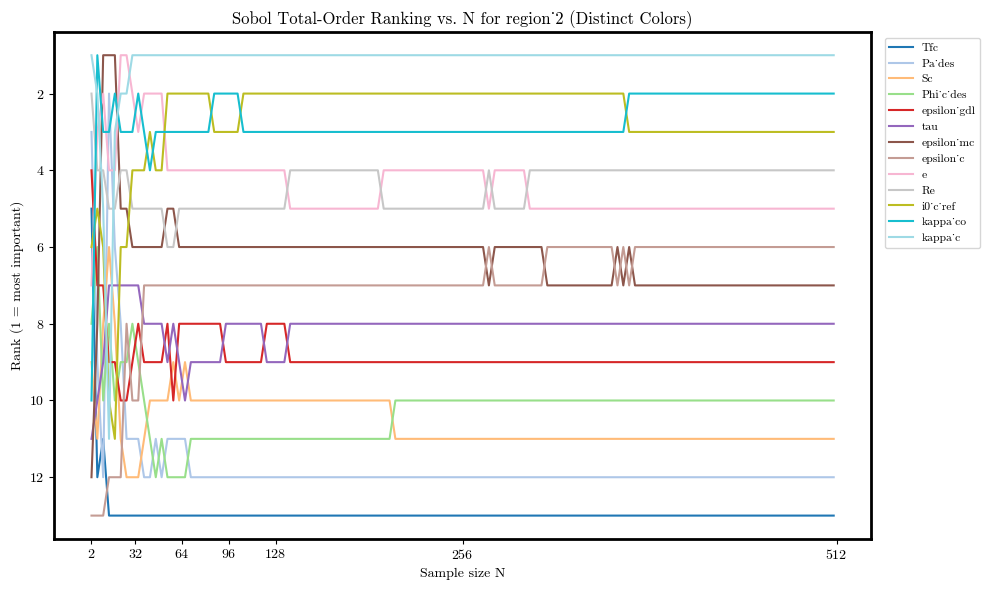

In [120]:
plot_rankings(rank_df,Ns)

d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))
d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\scipy\stats\_qmc.py:993: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)
d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or

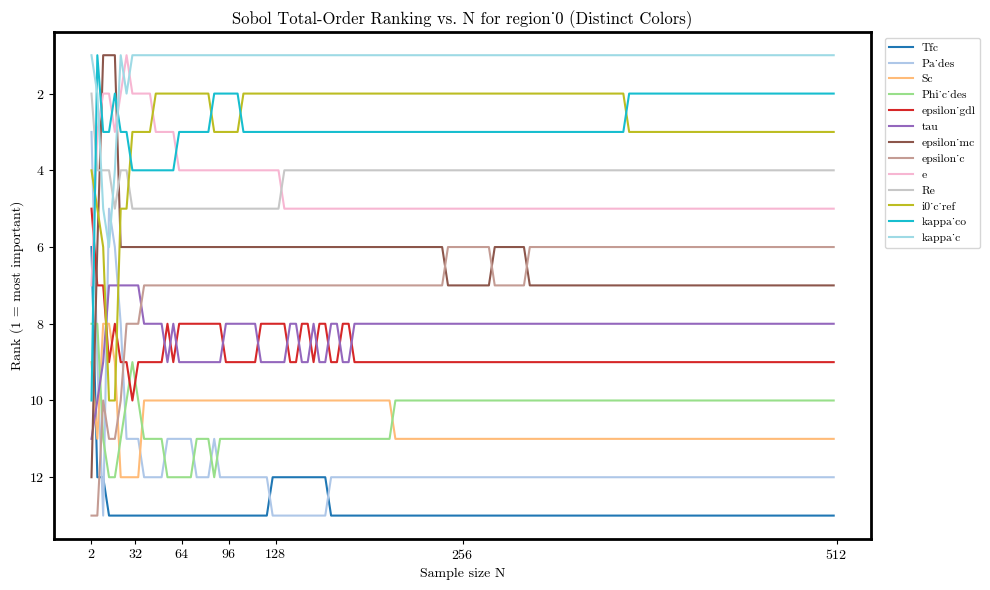

In [ ]:
rank_df_1region,indices_df_1region,indices_s1_df_1region = compute_rankings_for_Ns(parameter_ranges, final_imputed, Ns, aggregation_method="fPCA",by_regions=False)
plot_rankings(rank_df_1region,Ns)

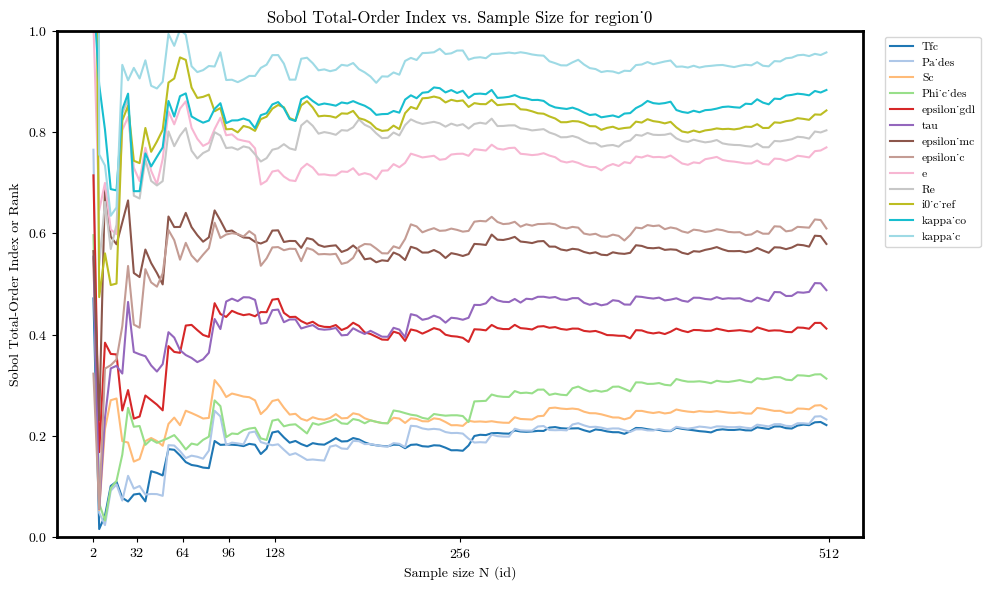

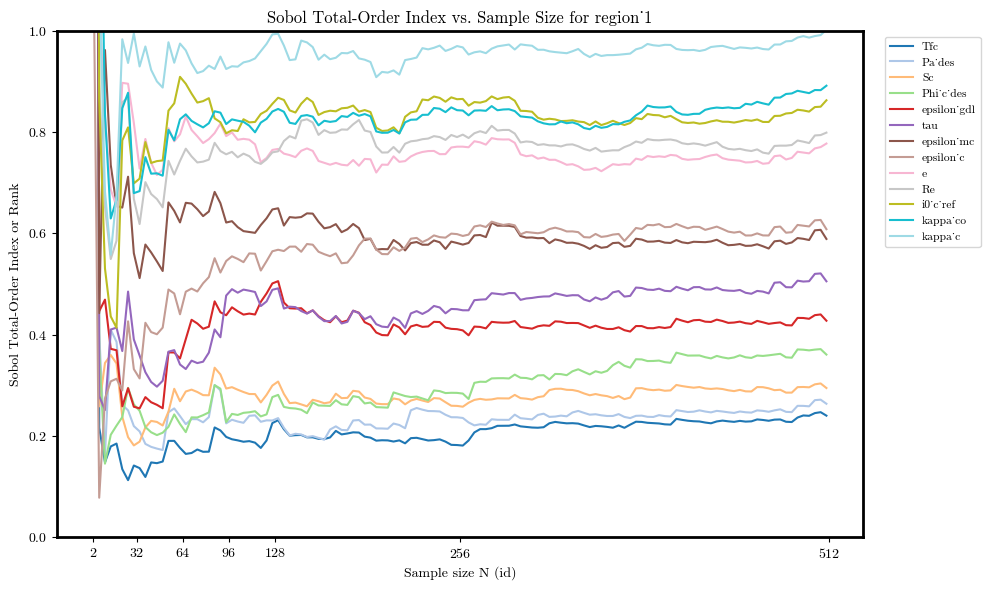

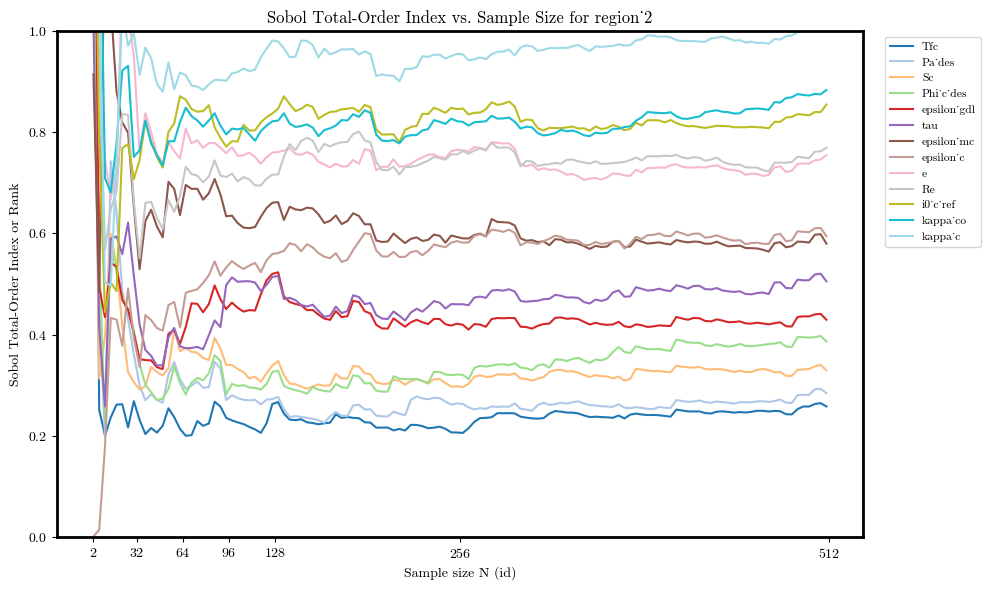

In [132]:
import matplotlib.pyplot as plt

# Assume rank_df has columns: ['id', 'feature', 'region_0', 'region_1', 'region_2', ...]

def plot_indices(indices_df):
    # Get the list of regions from columns
    regions = [col for col in indices_df.columns if col.startswith('region_')]

    # Sort unique sample sizes in 'id'
    Ns = sorted(indices_df['id'].unique())

    for region in regions:
        plt.figure(figsize=(10, 6))
        features = indices_df['feature'].unique()
        cmap = plt.get_cmap('tab20', len(features))

        for idx, feature in enumerate(features):
            # Select rows for this feature and sort by sample size
            df_feature = indices_df[indices_df['feature'] == feature].set_index('id').loc[Ns]

            # y values are Sobol indices/ranks for this feature in the current region
            y = df_feature[region]

            plt.plot(Ns, y, label=feature, color=cmap(idx))

        plt.xlabel("Sample size N (id)")
        plt.ylabel("Sobol Total-Order Index or Rank")
        plt.title(f"Sobol Total-Order Index vs. Sample Size for {region}")
        plt.xticks([2, 32, 64, 96, 128, 256, 512])
        plt.ylim(0, 1)
        plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize="small")
        plt.tight_layout()
        plt.show()
plot_indices(indices_df= indices_df)

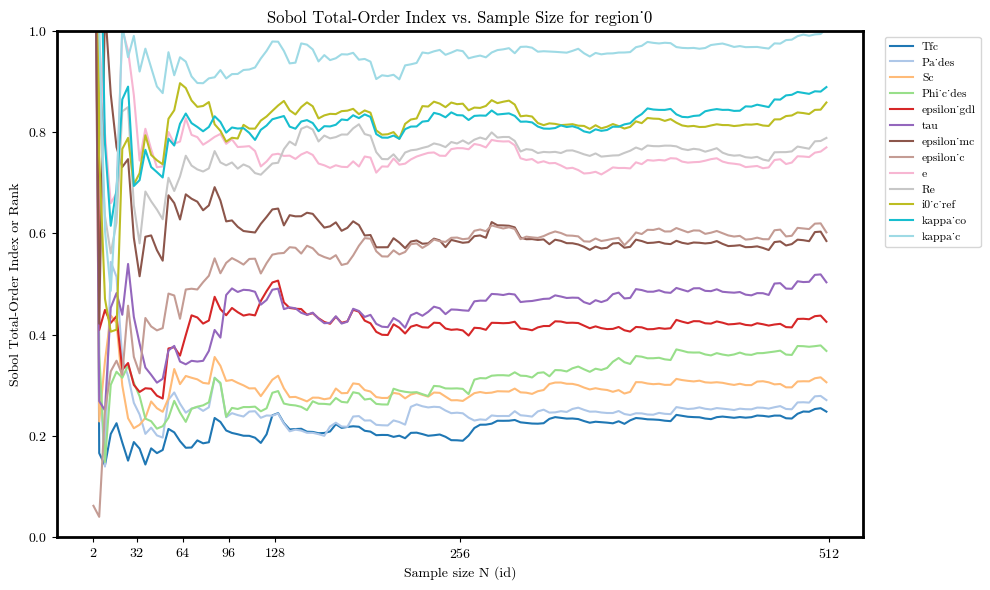

In [133]:
plot_indices(indices_df= indices_df_1region)